# # 09 — Next Campaign Recommendation (MVP 06)
#
# **Pipeline stage: hybrid recommendation engine for future campaigns.**
#
# Combines three layers:
#
# 1. **Business rules** — learned from history: best timing (quarter), best duration and
#    discount depth from top-ROI campaigns, avoid promoting substitution-heavy products
#    together.
# 2. **ML outputs** — the MVP 02 baseline models simulate each candidate scenario
#    (discount x duration) against the no-promotion counterfactual; the MVP 05 ranking
#    model provides a cross-check score.
# 3. **Optimization** — grid search over discount x duration under a budget, maximizing
#    expected incremental profit.
#
# The output is a structured, **LLM/MCP-ready** recommendation per product with an
# explicit evidence chain, so a future MCP tool can explain *why* in natural language.
#
# ```
# baseline models (05) + ranking (05) + ROI rules (03) + cannibalization report (04)
# + promotion history (01) + product relationships (PI)
#   -> rule layer (timing / duration / depth / pairing risk)
#   -> scenario simulation with the baseline models
#   -> optimization under budget
#   -> recommendations.parquet | recommendations.json (LLM-ready)
# ```


In [1]:
# --- environment --------------------------------------------------------------
import sys
import json
import warnings
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")

def _find_root() -> Path:
    p = Path.cwd()
    for q in [p, *p.parents]:
        if (q / "data" / "raw" / "transaction_data.csv").exists():
            return q
    return p

ROOT = _find_root()
sys.path.insert(0, str(ROOT / "notebooks"))

from utils import data as UD
from utils import common as UC

logger = UC.setup_logging("campaign_recommendation")


@dataclass(frozen=True)
class Config:
    """Single source of truth for MVP 06."""
    seed: int = 42
    n_candidates: int = 20               # top products to recommend for
    future_start_day: int = 712          # first day after the observed window
    discount_grid: tuple = (0.10, 0.15, 0.20, 0.25, 0.30)
    duration_grid: tuple = (7, 14, 21)
    budget_per_product: float = 5_000.0
    gross_margin: float = 0.30
    min_roi: float = 0.0                 # minimum expected ROI to recommend promoting
    substitution_risk_threshold: float = 0.75
    history_days: int = 28               # lag history used to build scenario rows
    output_dir: Path = UC.pipeline_dir("recommendation")
    figures_dir: Path = UC.figures_dir("recommendation")


CFG = Config()
UC.set_seed(CFG.seed)
print(f"Output dir  : {CFG.output_dir}")
print(f"Candidates  : {CFG.n_candidates} | discount grid {CFG.discount_grid} | "
      f"durations {CFG.duration_grid} | budget ${CFG.budget_per_product:,.0f}")


Output dir  : /home/mhseddighi/Projects/promotion-intelligence/outputs/recommendation
Candidates  : 20 | discount grid (0.1, 0.15, 0.2, 0.25, 0.3) | durations (7, 14, 21) | budget $5,000


# ## 1. Load Inputs (all prior MVP outputs + Product Intelligence)


In [2]:
bf = UC.OUTPUTS_ROOT / "baseline_forecast"
roi_dir = UC.OUTPUTS_ROOT / "roi_analysis"
promo_dir = UC.OUTPUTS_ROOT / "promotion_analysis"
cann_dir = UC.OUTPUTS_ROOT / "cannibalization"
pi_dir = UC.OUTPUTS_ROOT / "product_intelligence"

model_q = joblib.load(bf / "model_quantity.pkl")
model_r = joblib.load(bf / "model_revenue.pkl")
encoders = joblib.load(bf / "encoders.pkl")
with open(bf / "feature_cols.json") as f:
    feature_spec = json.load(f)
FEATURE_COLS = feature_spec["feature_cols"]
PROMO_ZERO_COLS = feature_spec["promo_zero_cols"]
CAT_COLS = feature_spec["cat_cols"]

baseline_pred = pd.read_parquet(bf / "baseline_predictions.parquet")
inc_product = pd.read_parquet(bf / "incremental_product.parquet")
campaign_roi = pd.read_parquet(roi_dir / "campaign_roi_summary.parquet")
promoted = pd.read_parquet(promo_dir / "promoted_products.parquet")
campaign_summary = pd.read_parquet(promo_dir / "campaign_summary.parquet")
cannibalization = pd.read_parquet(cann_dir / "campaign_cannibalization.parquet")
relationships = pd.read_parquet(pi_dir / "product_relationships.parquet")
product_features = pd.read_parquet(pi_dir / "product_features.parquet")
causal_weekly = UD.load_or_build_causal_weekly(logger=logger)
products = UD.load_products()

print(f"Feature cols: {len(FEATURE_COLS)} | promo-zero cols: {len(PROMO_ZERO_COLS)}")
print(f"baseline predictions: {baseline_pred.shape} | cannibalization rows: {len(cannibalization):,}")


23:06:41 | INFO    | campaign_recommendation | Loading cached causal_weekly from /home/mhseddighi/Projects/promotion-intelligence/data/processed/causal_weekly.parquet


Feature cols: 34 | promo-zero cols: 11
baseline predictions: (568800, 9) | cannibalization rows: 994


In [3]:
def validate_inputs() -> None:
    for name, obj in [("model_quantity", model_q), ("model_revenue", model_r)]:
        assert hasattr(obj, "predict"), f"{name} missing"
    assert len(FEATURE_COLS) >= 20
    assert baseline_pred["PRODUCT_ID"].nunique() == 800
    assert campaign_roi["CAMPAIGN"].nunique() == 30
    UC.check_no_nan_inf(baseline_pred[["PRODUCT_ID", "DAY", "quantity",
                                       "base_quantity", "base_revenue"]],
                        context="baseline_predictions")
    print("PASS: inputs validated")


validate_inputs()


PASS [nan/inf] baseline_predictions: no NaN/Inf in 568,800 rows
PASS: inputs validated


# ## 2. Business Rules from History
#
# Three simple, transparent rules are learned from the observed campaigns:
#
# - **Timing** — the quarter with the highest average sales uplift.
# - **Duration** — the median duration of top-quartile-ROI campaigns.
# - **Discount depth** — the median discount depth of top-quartile-ROI campaigns.


In [4]:
# --- timing rule --------------------------------------------------------------
summary_q = campaign_summary.copy()
summary_q["quarter"] = ((summary_q["START_DAY"] / 30).astype(int) % 12 // 3) + 1
timing_rule = (summary_q.groupby("quarter")["sales_uplift_pct"].mean()
               .sort_values(ascending=False))
best_quarter = int(timing_rule.index[0])
print("=== Timing rule (avg sales uplift % by quarter) ===")
print(timing_rule.round(1).to_string())
print(f"Best quarter to promote: Q{best_quarter}")

# --- duration + discount rules --------------------------------------------------
camp_depth = (promoted.groupby("CAMPAIGN")["discount_depth"].mean().rename("camp_discount_depth"))
roi_rules = campaign_roi.merge(camp_depth, on="CAMPAIGN", how="left")
top_roi = roi_rules[roi_rules["roi"] >= roi_rules["roi"].quantile(0.75)]
duration_rule = int(top_roi["duration_days"].median())
discount_rule = float(top_roi["camp_discount_depth"].median())
print(f"\n=== Duration rule ===  median duration of top-quartile-ROI campaigns: {duration_rule} days")
print(f"=== Discount rule ===  median discount depth of top-quartile-ROI campaigns: {discount_rule:.1%}")

# --- pairing risk: high-substitution pairs among candidates ---------------------
candidate_ids = (baseline_pred.groupby("PRODUCT_ID")["quantity"].sum()
                 .nlargest(CFG.n_candidates).index.tolist())
cand_set = set(candidate_ids)
risk_pairs = relationships[
    (relationships["product_a"].isin(cand_set)) &
    (relationships["product_b"].isin(cand_set)) &
    (relationships["substitution_score"] >= CFG.substitution_risk_threshold)
][["product_a", "product_b", "substitution_score", "confidence_score"]]
print(f"\n=== Pairing risk === {len(risk_pairs)} high-substitution pairs among candidates")


=== Timing rule (avg sales uplift % by quarter) ===
quarter
3    4.7
1    1.1
2   -0.4
4   -0.6
Best quarter to promote: Q3

=== Duration rule ===  median duration of top-quartile-ROI campaigns: 34 days
=== Discount rule ===  median discount depth of top-quartile-ROI campaigns: 24.1%



=== Pairing risk === 14 high-substitution pairs among candidates


In [5]:
def validate_rules() -> None:
    assert 1 <= best_quarter <= 4
    assert duration_rule > 0 and 0 < discount_rule < 1
    assert len(candidate_ids) == CFG.n_candidates
    print("PASS: business rules learned")


validate_rules()


PASS: business rules learned


# ## 3. Scenario Simulation with the Baseline Models
#
# For each candidate product and each (discount, duration) scenario we build a feature
# row for a future promotion window and predict twice with the MVP 02 models:
#
# - **Scenario** — promotion features set to the scenario design.
# - **Baseline** — same row with promotion features zeroed (no promotion).
#
# Lag/rolling features use the observed history from `baseline_predictions.parquet`,
# exactly as the models were trained. Estimated discount spend is derived from the
# scenario revenue: `cost = scenario_revenue × discount / (1 − discount)`.


In [6]:
# per-product promo context (typical display/mailer intensity while promoted)
causal_prod = (causal_weekly[causal_weekly["PRODUCT_ID"].isin(candidate_ids)]
               .groupby("PRODUCT_ID")[["display_share", "mailer_share"]].mean())
prod_features = (product_features[product_features["PRODUCT_ID"].isin(candidate_ids)]
                 .set_index("PRODUCT_ID"))
history = baseline_pred[baseline_pred["PRODUCT_ID"].isin(candidate_ids)].set_index(
    ["PRODUCT_ID", "DAY"])


def build_scenario_row(pid: int, day: int, discount: float, duration: int,
                       display_share: float, mailer_share: float) -> pd.DataFrame:
    """One feature row for a future scenario, matching the MVP 02 schema."""
    h = history.loc[pid]
    q_hist = h["quantity"].reindex(range(day - CFG.history_days, day)).fillna(0.0)
    sales_hist = h["sales_value"].reindex(range(day - CFG.history_days, day)).fillna(0.0)

    row = {"PRODUCT_ID": pid, "DAY": day}
    row["has_discount"] = 1
    row["discount_rate"] = discount
    row["total_discount"] = float(discount * sales_hist.tail(7).mean())
    row["retail_disc"] = -row["total_discount"]
    row["coupon_disc"] = 0.0
    row["has_display"] = int(display_share > 0)
    row["has_mailer"] = int(mailer_share > 0)
    row["display_share"] = float(display_share)
    row["mailer_share"] = float(mailer_share)
    row["promo_intensity"] = float(display_share + mailer_share)
    row["campaign_active"] = 1

    for lag in [1, 2, 3, 7, 14, 28]:
        row[f"lag_{lag}"] = float(q_hist.iloc[-lag]) if lag <= len(q_hist) else 0.0
    for w in [7, 14, 28]:
        win = q_hist.iloc[-w:] if w <= len(q_hist) else q_hist
        row[f"rolling_mean_{w}"] = float(win.mean()) if len(win) else 0.0
        row[f"rolling_std_{w}"] = float(win.std()) if len(win) > 1 else 0.0

    row["day_of_week"] = int(day % 7)
    row["month"] = int(((day / 30) % 12) + 1)
    row["quarter"] = int(((day / 30) % 12 // 3) + 1)
    row["week_of_year"] = int((day / 7) % 52)
    row["is_weekend"] = int((day % 7) >= 5)

    pf = prod_features.loc[pid]
    row["avg_price"] = float(pf.get("avg_price", np.nan))
    row["product_discount_rate"] = float(pf.get("discount_rate", 0.0))
    row["sales_frequency"] = float(pf.get("sales_frequency", 0.0))
    row["volatility"] = float(pf.get("volatility", 0.0))
    row["total_sales"] = float(pf.get("total_sales", 0.0))
    for col in CAT_COLS:
        if col in encoders and f"{col}_enc" in FEATURE_COLS:
            val = str(pf.get(col, "unknown"))
            row[f"{col}_enc"] = int(encoders[col].transform([[val]])[0][0])

    out = pd.DataFrame([{c: row.get(c, 0.0) for c in FEATURE_COLS}])
    out["PRODUCT_ID"] = pid
    out["DAY"] = day
    out["duration_days"] = duration
    return out


In [7]:
scenario_rows = []
for pid in candidate_ids:
    ds = causal_prod.loc[pid, "display_share"] if pid in causal_prod.index else 0.0
    ms = causal_prod.loc[pid, "mailer_share"] if pid in causal_prod.index else 0.0
    for disc in CFG.discount_grid:
        for dur in CFG.duration_grid:
            row = build_scenario_row(pid, CFG.future_start_day, disc, dur, ds, ms)
            scenario_rows.append(row)
scen = pd.concat(scenario_rows, ignore_index=True)
print(f"Scenarios: {len(scen):,} ({len(candidate_ids)} products x "
      f"{len(CFG.discount_grid)} discounts x {len(CFG.duration_grid)} durations)")

X_scen = scen[FEATURE_COLS]
X_base = X_scen.copy()
for col in PROMO_ZERO_COLS:
    if col in X_base.columns:
        X_base[col] = 0.0
scen["scenario_qty"] = model_q.predict(X_scen).clip(min=0)
scen["scenario_rev"] = model_r.predict(X_scen).clip(min=0)
scen["baseline_qty"] = model_q.predict(X_base).clip(min=0)
scen["baseline_rev"] = model_r.predict(X_base).clip(min=0)
scen["incremental_qty"] = scen["scenario_qty"] - scen["baseline_qty"]
scen["incremental_rev"] = scen["scenario_rev"] - scen["baseline_rev"]
scen["promotion_cost"] = np.where(
    scen["discount_rate"] < 1,
    scen["scenario_rev"] * scen["discount_rate"] / (1 - scen["discount_rate"]), 0.0)
scen["incremental_profit"] = CFG.gross_margin * scen["incremental_rev"] - scen["promotion_cost"]
scen["roi"] = np.where(scen["promotion_cost"] > 0,
                       scen["incremental_profit"] / scen["promotion_cost"], 0.0)
scen["within_budget"] = (scen["promotion_cost"] <= CFG.budget_per_product).astype(int)
print(scen[["PRODUCT_ID", "discount_rate", "duration_days", "incremental_qty",
            "incremental_rev", "promotion_cost", "incremental_profit", "roi"]]
      .sort_values("incremental_profit", ascending=False).head(8).round(2).to_string(index=False))


Scenarios: 300 (20 products x 5 discounts x 3 durations)
 PRODUCT_ID  discount_rate  duration_days  incremental_qty  incremental_rev  promotion_cost  incremental_profit  roi
    6533889           0.10             14         56566.74           135.11           15.08               25.46 1.69
    6533889           0.10             21         56566.74           135.11           15.08               25.46 1.69
    6533889           0.10              7         56566.74           135.11           15.08               25.46 1.69
    6533889           0.15             14         57526.60           116.19           20.60               14.25 0.69
    6533889           0.15              7         57526.60           116.19           20.60               14.25 0.69
    6533889           0.15             21         57526.60           116.19           20.60               14.25 0.69
    6534166           0.10              7         39527.24            67.15            7.46               12.68 1.70
    653

In [8]:
def validate_scenarios() -> None:
    assert len(scen) == len(candidate_ids) * len(CFG.discount_grid) * len(CFG.duration_grid)
    UC.check_no_nan_inf(scen[["PRODUCT_ID", "scenario_qty", "scenario_rev",
                              "baseline_qty", "baseline_rev", "incremental_profit",
                              "roi", "promotion_cost"]], context="scenarios")
    assert (scen["scenario_qty"] >= 0).all() and (scen["scenario_rev"] >= 0).all()
    print("PASS: scenario simulation validated")


validate_scenarios()


PASS [nan/inf] scenarios: no NaN/Inf in 300 rows
PASS: scenario simulation validated


# ## 4. Optimization & Recommendation
#
# Per product we keep the best in-budget scenario by expected incremental profit. The
# product is recommended for promotion only when that scenario has positive expected
# profit and ROI above the threshold. Risks are attached from the cannibalization
# report and the relationship graph.


In [9]:
# --- cannibalization risk per candidate (lost revenue when co-promoted historically)
cann_risk = (cannibalization[cannibalization["affected_pid"].isin(cand_set)]
             .groupby("affected_pid")["lost_revenue"].sum().rename("cannibalization_risk"))
cann_source = (cannibalization[cannibalization["top_source"].isin(cand_set)]
               .groupby("top_source")["lost_revenue"].sum().rename("cannibalizes_others"))

# --- historical confidence per product (from MVP 02) ---------------------------
conf_map = (inc_product[inc_product["PRODUCT_ID"].isin(cand_set)]
            .groupby("PRODUCT_ID")["confidence_qty"].mean())

best = (scen[scen["within_budget"] == 1]
        .sort_values("incremental_profit", ascending=False)
        .groupby("PRODUCT_ID").head(1))

recs = best.merge(products[["PRODUCT_ID", "COMMODITY_DESC", "DEPARTMENT"]],
                  on="PRODUCT_ID", how="left")
recs["whether_to_promote"] = ((recs["incremental_profit"] > 0) & (recs["roi"] >= CFG.min_roi))
recs["best_timing_quarter"] = best_quarter
recs["cannibalization_risk"] = recs["PRODUCT_ID"].map(cann_risk).fillna(0.0)
recs["cannibalizes_others"] = recs["PRODUCT_ID"].map(cann_source).fillna(0.0)
recs["historical_confidence"] = recs["PRODUCT_ID"].map(conf_map).fillna(0.5)
recs["margin_risk"] = (recs["discount_rate"] > CFG.gross_margin).astype(int)

# products to avoid promoting together with this product
avoid = risk_pairs[risk_pairs["product_a"].isin(cand_set) | risk_pairs["product_b"].isin(cand_set)]
avoid_map = {}
for _, r in avoid.iterrows():
    avoid_map.setdefault(int(r["product_a"]), []).append(
        {"product_id": int(r["product_b"]),
         "substitution_score": round(float(r["substitution_score"]), 3)})
    avoid_map.setdefault(int(r["product_b"]), []).append(
        {"product_id": int(r["product_a"]),
         "substitution_score": round(float(r["substitution_score"]), 3)})
recs["avoid_promoting_with"] = recs["PRODUCT_ID"].map(
    lambda p: sorted(avoid_map.get(int(p), []), key=lambda x: -x["substitution_score"]))

recs = recs.sort_values(["whether_to_promote", "incremental_profit"],
                        ascending=[False, False]).reset_index(drop=True)
UC.save_parquet(recs, CFG.output_dir / "campaign_recommendations.parquet",
                logger=logger, context="campaign_recommendations")
print(recs[["PRODUCT_ID", "COMMODITY_DESC", "whether_to_promote", "discount_rate",
            "duration_days", "incremental_profit", "roi", "promotion_cost",
            "cannibalization_risk"]].round(3).to_string(index=False))


23:06:47 | INFO    | campaign_recommendation | [campaign_recommendations] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/recommendation/campaign_recommendations.parquet (20 rows x 56 cols)


 PRODUCT_ID         COMMODITY_DESC  whether_to_promote  discount_rate  duration_days  incremental_profit    roi  promotion_cost  cannibalization_risk
    6533889      COUPON/MISC ITEMS                True            0.1             14              25.457  1.689          15.075                 0.000
    6534166      COUPON/MISC ITEMS                True            0.1              7              12.684  1.700           7.461                 0.000
    6544236      COUPON/MISC ITEMS                True            0.1             21               4.560  1.700           2.682                 0.000
     480014      COUPON/MISC ITEMS                True            0.1              7               2.175  1.700           1.280                 0.000
    1404121      COUPON/MISC ITEMS                True            0.1             14               1.508  1.681           0.897                 0.000
     397896      COUPON/MISC ITEMS                True            0.1             21               1

In [10]:
def validate_recommendations() -> None:
    assert len(recs) == CFG.n_candidates
    assert recs["PRODUCT_ID"].is_unique
    UC.check_no_nan_inf(recs[["PRODUCT_ID", "discount_rate", "duration_days",
                              "incremental_profit", "roi", "promotion_cost",
                              "cannibalization_risk"]], context="recommendations")
    assert (recs["duration_days"].isin(CFG.duration_grid)).all()
    assert (recs["discount_rate"].isin(CFG.discount_grid)).all()
    print("PASS: recommendations validated")


validate_recommendations()


PASS [nan/inf] recommendations: no NaN/Inf in 20 rows
PASS: recommendations validated


# ## 5. LLM / MCP-Ready Explanation
#
# Every recommendation carries an **evidence chain** — the exact inputs a future MCP
# tool can render as natural-language rationale.


In [11]:
report = {"schema_version": "1.0", "generated_for_day": CFG.future_start_day,
          "rules": {
              "best_timing_quarter": best_quarter,
              "duration_rule_days": duration_rule,
              "discount_rule": round(discount_rule, 4),
              "min_roi": CFG.min_roi,
              "budget_per_product": CFG.budget_per_product,
          },
          "recommendations": []}

for _, r in recs.iterrows():
    avoid_txt = "; ".join(
        f"product {a['product_id']} (substitution score {a['substitution_score']})"
        for a in r["avoid_promoting_with"][:3]) or "none among candidates"
    risks = []
    if r["cannibalization_risk"] > 0:
        risks.append(f"historically loses ${r['cannibalization_risk']:,.0f} to cannibalization")
    if r["margin_risk"]:
        risks.append("discount exceeds gross margin (negative gross margin on discounted units)")
    if r["cannibalizes_others"] > 0:
        risks.append(f"historically cannibalizes other products (${r['cannibalizes_others']:,.0f} attributed)")
    if not risks:
        risks.append("no material risk flags from historical analysis")

    report["recommendations"].append({
        "product_id": int(r["PRODUCT_ID"]),
        "commodity": r["COMMODITY_DESC"],
        "department": r["DEPARTMENT"],
        "whether_to_promote": bool(r["whether_to_promote"]),
        "suggested_discount": float(r["discount_rate"]),
        "suggested_duration_days": int(r["duration_days"]),
        "best_timing_quarter": int(r["best_timing_quarter"]),
        "expected_incremental_qty": round(float(r["incremental_qty"]), 1),
        "expected_incremental_revenue": round(float(r["incremental_rev"]), 2),
        "expected_promotion_cost": round(float(r["promotion_cost"]), 2),
        "expected_incremental_profit": round(float(r["incremental_profit"]), 2),
        "expected_roi": round(float(r["roi"]), 3),
        "confidence": round(float(r["historical_confidence"]), 3),
        "risks": risks,
        "avoid_promoting_with": r["avoid_promoting_with"][:3],
        "evidence_chain": [
            {"source": "baseline_forecast",
             "detail": (f"baseline model predicts {r['baseline_rev']:.0f} USD revenue without "
                        f"promotion vs {r['scenario_rev']:.0f} USD with "
                        f"{r['discount_rate']:.0%} discount over {int(r['duration_days'])} days")},
            {"source": "roi_analysis",
             "detail": f"expected ROI {r['roi']:.2f} at {CFG.gross_margin:.0%} margin "
                       f"(threshold {CFG.min_roi})"},
            {"source": "campaign_ranking",
             "detail": f"best historical timing is quarter Q{best_quarter}; top-quartile ROI "
                       f"campaigns used ~{duration_rule} days and ~{discount_rule:.0%} depth"},
            {"source": "cannibalization",
             "detail": (f"avoid promoting together with: {avoid_txt}; historical "
                        f"cannibalization exposure ${r['cannibalization_risk']:,.0f}")},
        ],
    })

UC.save_json(report, CFG.output_dir / "recommendations.json", logger=logger,
             context="recommendations.json")
print(f"LLM-ready recommendations written for {len(report['recommendations'])} products")


23:06:47 | INFO    | campaign_recommendation | [recommendations.json] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/recommendation/recommendations.json


LLM-ready recommendations written for 20 products


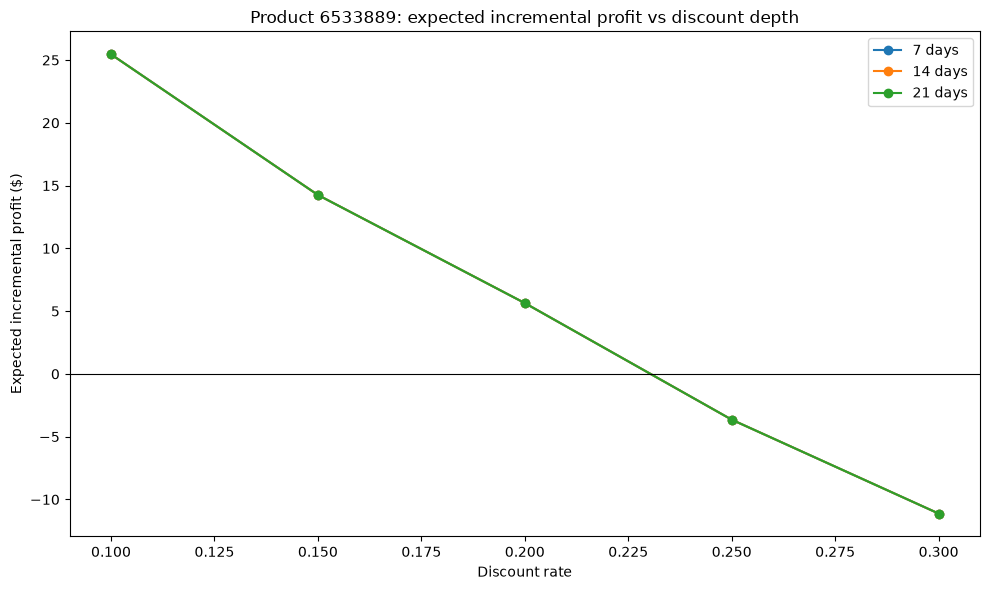

In [12]:
# Figure 1: scenario frontier for the highest-value candidate
top_pid = int(recs.iloc[0]["PRODUCT_ID"])
frontier = scen[scen["PRODUCT_ID"] == top_pid].copy()
fig, ax = plt.subplots(figsize=(10, 6))
for dur in CFG.duration_grid:
    d = frontier[frontier["duration_days"] == dur]
    ax.plot(d["discount_rate"], d["incremental_profit"], marker="o",
            label=f"{dur} days")
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Product {top_pid}: expected incremental profit vs discount depth")
ax.set_xlabel("Discount rate"); ax.set_ylabel("Expected incremental profit ($)")
ax.legend()
plt.tight_layout()
fig.savefig(CFG.figures_dir / "scenario_frontier.png", dpi=110)
plt.show()


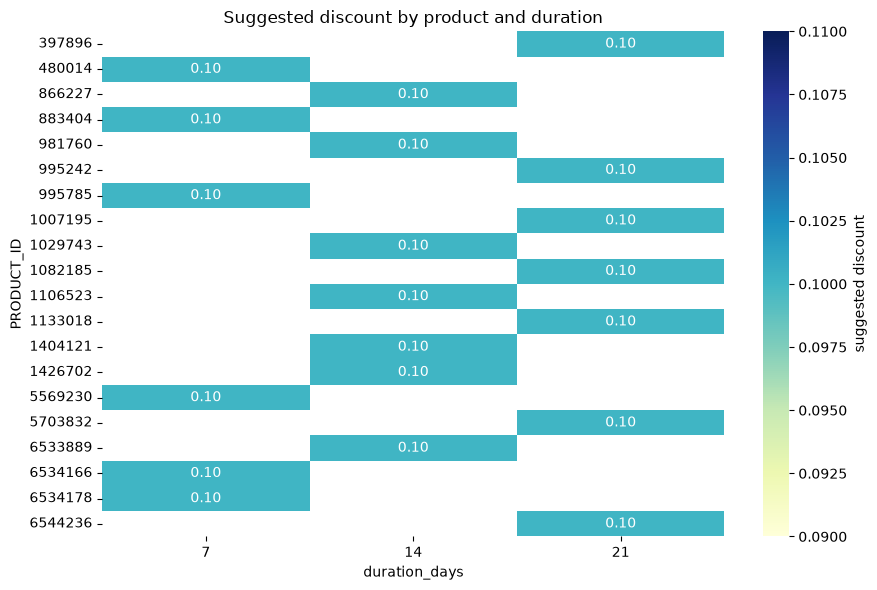

In [13]:
# Figure 2: recommended discount / duration heatmap
fig, ax = plt.subplots(figsize=(9, 6))
pivot = recs.pivot_table(index="PRODUCT_ID", columns="duration_days",
                         values="discount_rate", aggfunc="first")
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax,
            cbar_kws={"label": "suggested discount"})
ax.set_title("Suggested discount by product and duration")
plt.tight_layout()
fig.savefig(CFG.figures_dir / "discount_duration_heatmap.png", dpi=110)
plt.show()


# ## 6. Validation — Exports, Schema and Reload


In [14]:
def validate_exports() -> None:
    out = CFG.output_dir
    r = UC.reload_and_check(out / "campaign_recommendations.parquet",
        expected=["PRODUCT_ID", "whether_to_promote", "discount_rate", "duration_days",
                  "incremental_profit", "roi", "promotion_cost",
                  "best_timing_quarter", "cannibalization_risk"],
        context="campaign_recommendations")
    assert len(r) == CFG.n_candidates
    rep_path = out / "recommendations.json"
    assert rep_path.exists()
    with open(rep_path) as f:
        rep = json.load(f)
    assert rep["schema_version"] == "1.0"
    assert len(rep["recommendations"]) == CFG.n_candidates
    sample = rep["recommendations"][0]
    assert "evidence_chain" in sample and "risks" in sample and "avoid_promoting_with" in sample
    print("PASS: MVP 06 exports validated")


validate_exports()


PASS [nan/inf] reload campaign_recommendations.parquet: no NaN/Inf in 20 rows
PASS [schema] reload campaign_recommendations.parquet: 56 columns OK
PASS [reload] campaign_recommendations: campaign_recommendations.parquet -> 20 rows
PASS: MVP 06 exports validated


In [15]:
# Pipeline manifest snippet
manifest = {
    "notebook": "09_campaign_recommendation",
    "mvp": "MVP 06 — Next Campaign Recommendation",
    "inputs": [
        "outputs/baseline_forecast/model_quantity.pkl",
        "outputs/baseline_forecast/model_revenue.pkl",
        "outputs/baseline_forecast/feature_cols.json",
        "outputs/baseline_forecast/encoders.pkl",
        "outputs/baseline_forecast/baseline_predictions.parquet",
        "outputs/baseline_forecast/incremental_product.parquet",
        "outputs/roi_analysis/campaign_roi_summary.parquet",
        "outputs/promotion_analysis/campaign_summary.parquet",
        "outputs/promotion_analysis/promoted_products.parquet",
        "outputs/cannibalization/campaign_cannibalization.parquet",
        "outputs/product_intelligence/product_relationships.parquet",
        "outputs/product_intelligence/product_features.parquet",
        "data/processed/causal_weekly.parquet",
        "data/raw/product.csv",
    ],
    "outputs": [
        "outputs/recommendation/campaign_recommendations.parquet",
        "outputs/recommendation/recommendations.json",
    ],
    "artifacts": {
        "campaign_recommendations.parquet": "per-product recommended scenario (discount, duration, timing)",
        "recommendations.json": "LLM/MCP-ready recommendations with evidence chains and risks",
    },
    "design": "hybrid: business rules + MVP 02 model simulation + grid optimization under budget",
}
print(json.dumps(manifest, indent=2))


{
  "notebook": "09_campaign_recommendation",
  "mvp": "MVP 06 \u2014 Next Campaign Recommendation",
  "inputs": [
    "outputs/baseline_forecast/model_quantity.pkl",
    "outputs/baseline_forecast/model_revenue.pkl",
    "outputs/baseline_forecast/feature_cols.json",
    "outputs/baseline_forecast/encoders.pkl",
    "outputs/baseline_forecast/baseline_predictions.parquet",
    "outputs/baseline_forecast/incremental_product.parquet",
    "outputs/roi_analysis/campaign_roi_summary.parquet",
    "outputs/promotion_analysis/campaign_summary.parquet",
    "outputs/promotion_analysis/promoted_products.parquet",
    "outputs/cannibalization/campaign_cannibalization.parquet",
    "outputs/product_intelligence/product_relationships.parquet",
    "outputs/product_intelligence/product_features.parquet",
    "data/processed/causal_weekly.parquet",
    "data/raw/product.csv"
  ],
  "outputs": [
    "outputs/recommendation/campaign_recommendations.parquet",
    "outputs/recommendation/recommendatio